**<center><font size=7> AI-Driven Financial News Sentiment Analysis & Stock Market Prediction</font></center>**

<center><p float="center">
  <img src="https://images.stockcake.com/public/7/c/0/7c0bd3ad-68fe-4b5a-bbf3-97774b7c568e_large/stock-market-graph-stockcake.jpg" width="720"/>
</p></center>


## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

This cell installs the required Python libraries for the project, including `numpy`, `scikit-learn`, `scipy`, `gensim`, `sentence-transformers`, and `pandas`.

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

This cell imports all the necessary libraries for data manipulation, visualization, word embeddings, deep learning, model building, and evaluation. It also sets a pandas option to display maximum column width and suppresses warnings.

## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell mounts Google Drive to access files stored in your Drive, which is a common practice in Google Colab for loading datasets.

In [4]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/stock_news.csv")

This cell loads the `stock_news.csv` dataset into a pandas DataFrame named `News` from the specified Google Drive path.

In [5]:
# creating a copy of the data
data = News.copy()

This cell creates a copy of the original `News` DataFrame and assigns it to a new DataFrame named `data` to avoid modifying the original data.

## **Data Overview**

###**Checking the first 5 rows**

In [6]:
display(data.head())

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


This cell displays the first 5 rows of the `data` DataFrame, providing a quick overview of the dataset's structure and content.

###**Checking the last 5 rows**

In [7]:
display(data.tail())

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


This cell displays the last 5 rows of the `data` DataFrame, allowing a quick check of the end of the dataset.

###**Checking the shape of the data**

In [8]:
print(data.shape)

(349, 8)


This cell prints the shape (number of rows and columns) of the `data` DataFrame.

###**Checking for missing values**

In [9]:
print(data.isnull().sum())

Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64


This cell checks for missing values in each column of the `data` DataFrame and prints the sum of null values per column.

### **Checking for duplicate values**

In [10]:
# checking for duplicate values
print(data.duplicated().sum())

0


This cell checks for duplicate rows in the `data` DataFrame and prints the count of such duplicates.

## **Exploratory Data Analysis**

In [11]:
# To display the structure of data
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


None

This cell displays a concise summary of the `data` DataFrame, including data types of each column, non-null values, and memory usage.

In [12]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

This cell converts the 'Date' column from an object type to a datetime object, which is essential for time-series analysis.

In [13]:
# To ensure the data type of Date
display(data['Date'].dtype)

dtype('<M8[ns]')

This cell displays the data type of the 'Date' column to confirm that the conversion to datetime was successful.

In [14]:
# summary statistics for each numeric column
display(data.describe())

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


This cell generates descriptive statistics for all numerical columns in the `data` DataFrame, providing insights into central tendency, dispersion, and shape of the distributions.

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

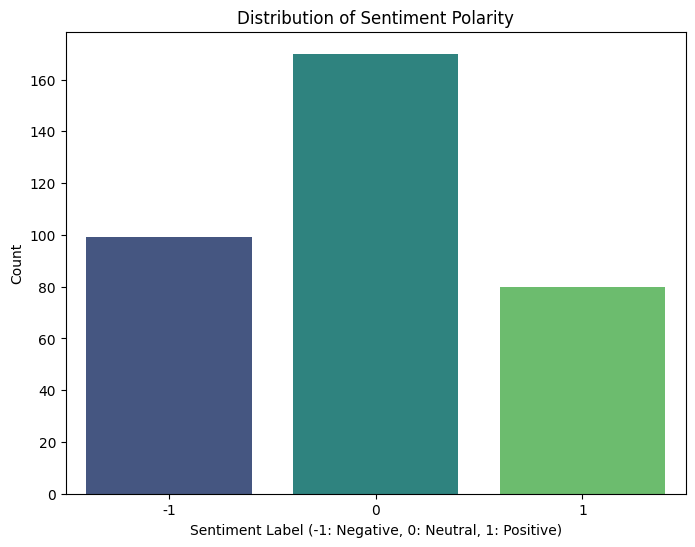

In [15]:
# Distribution of sentiment polarity
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=data, palette='viridis')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.show()

This cell generates a count plot to visualize the distribution of sentiment polarity (Label) in the dataset. It shows the frequency of negative (-1), neutral (0), and positive (1) sentiment labels.

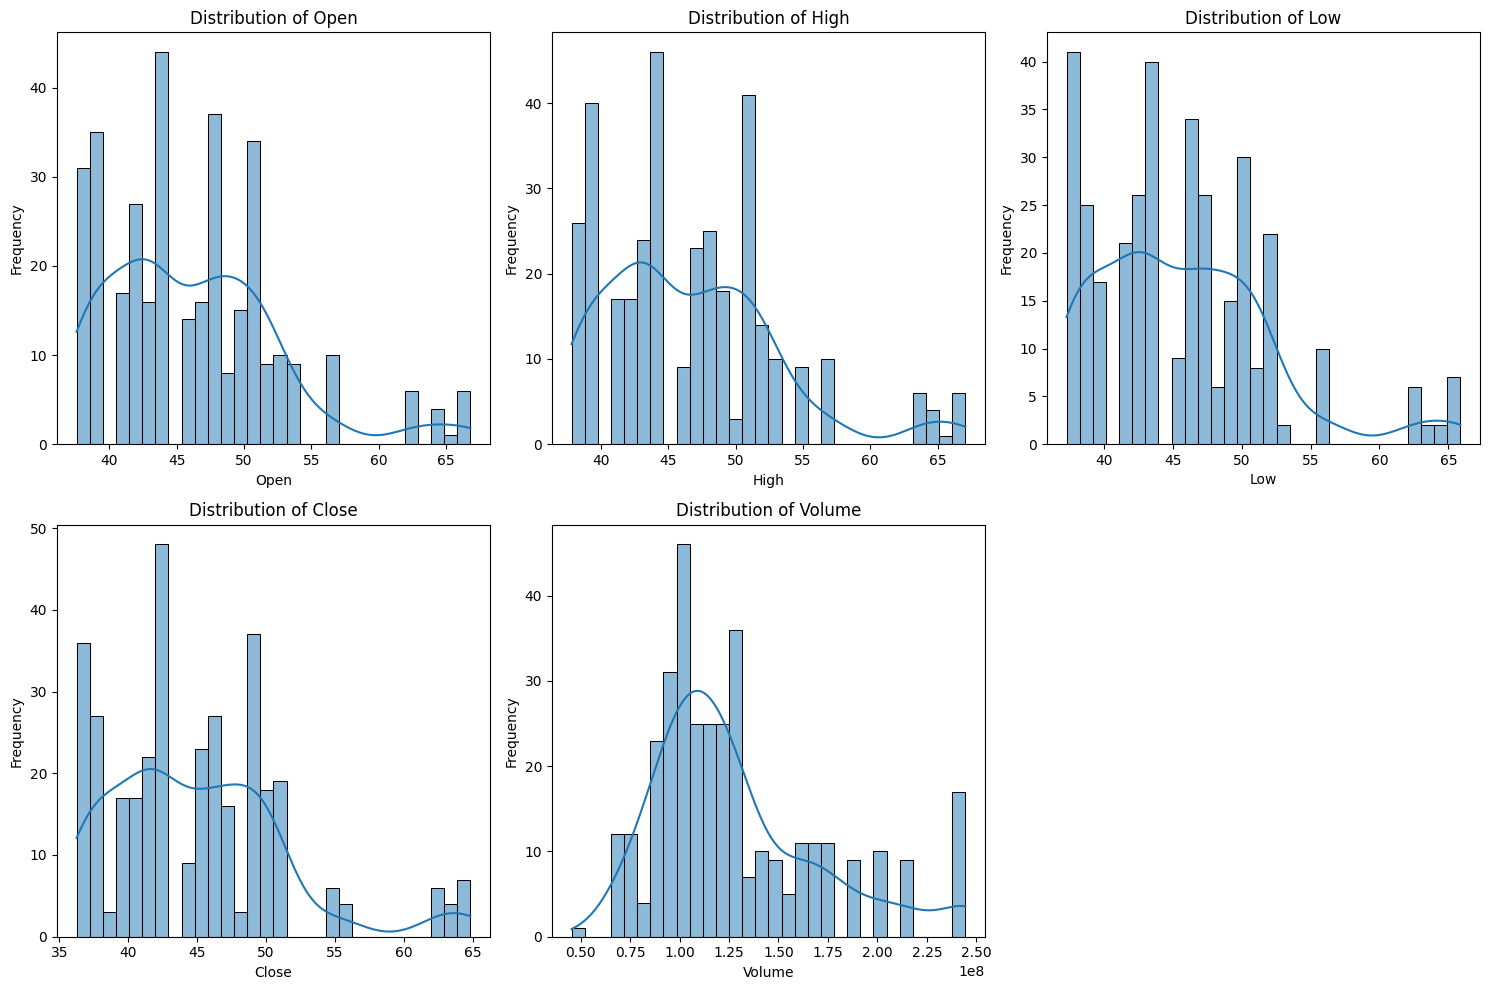

In [16]:
# Plot Distribution of all Numeric variables

# Select numerical columns (excluding 'Label' which is sentiment polarity)
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns
    sns.histplot(data[col], kde=True, bins=30, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This cell plots the distribution of all numerical variables ('Open', 'High', 'Low', 'Close', 'Volume') using histograms with KDE (Kernel Density Estimate) to show their frequency and density.

### **Distribution of the length of news content**

In [17]:
# Compute length of news content (in words)
data['news_length'] = data['News'].apply(lambda x: len(str(x).split()))

# Summary statistics of news length
print("Summary statistics of News Length:")
display(data['news_length'].describe())

Summary statistics of News Length:


,news_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


This cell calculates the length (in words) of each news article and stores it in a new column called 'news_length'. It then prints the summary statistics for this new column.

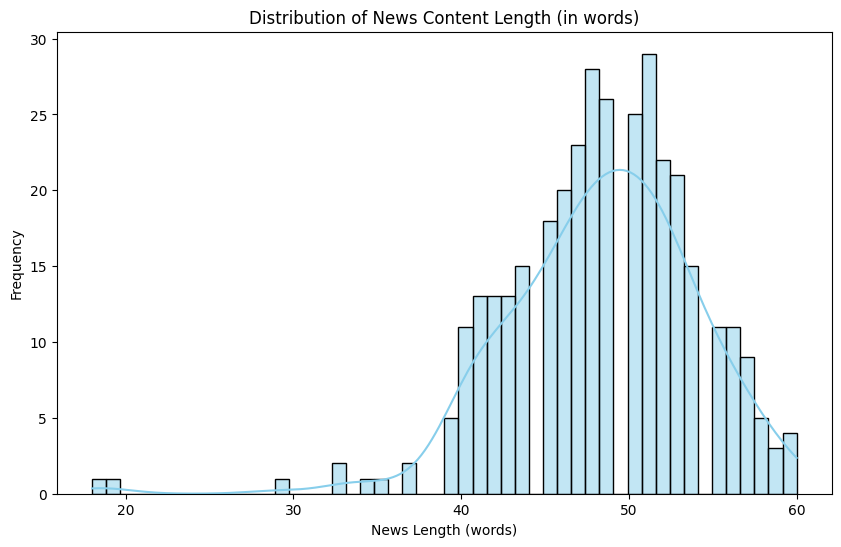

In [18]:
# Plot distribution of news length
plt.figure(figsize=(10, 6))
sns.histplot(data['news_length'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of News Content Length (in words)')
plt.xlabel('News Length (words)')
plt.ylabel('Frequency')
plt.show()

This cell visualizes the distribution of news content length (in words) using a histogram with a KDE plot, showing the frequency and density of different news lengths.

### **Monthwise Analysis**

In [19]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print("Monthwise Averages:")
display(monthwise_avg)

Monthwise Averages:


,YearMonth,High,Low,Open,Close,Volume
0,2019-01,44.024216,43.023629,43.550407,42.252099,1.393266e+08
1,2019-02,48.140754,47.365095,47.674387,46.376751,1.013622e+08
2,2019-03,48.007575,46.920933,47.566045,46.139134,1.413169e+08
3,2019-04,51.150357,50.304246,50.650277,49.462640,1.116555e+08


This cell creates a 'YearMonth' column from the 'Date' column, groups the data by 'YearMonth', and then calculates the average 'High', 'Low', 'Open', 'Close', and 'Volume' for each month, displaying the result.

<Figure size 1200x600 with 0 Axes>

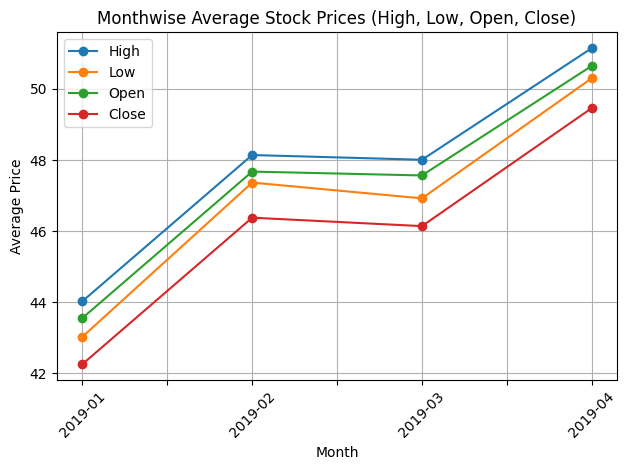

In [20]:
# plot the monthwise averages of all price variables for better visualization

plt.figure(figsize=(12, 6))
monthwise_avg.plot(x='YearMonth', y=['High', 'Low', 'Open', 'Close'], kind='line', marker='o')
plt.title('Monthwise Average Stock Prices (High, Low, Open, Close)')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell generates a line plot to visualize the month-wise average stock prices (High, Low, Open, Close), showing the trends of these price variables over time.

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

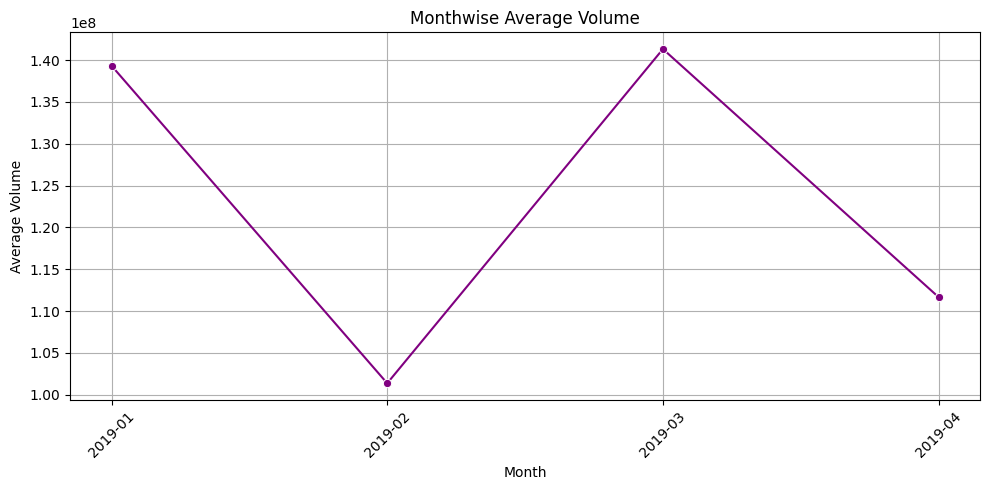

In [21]:
#plot the trend of monthwise averages in Volume

plt.figure(figsize=(10, 5))
sns.lineplot(x='YearMonth', y='Volume', data=monthwise_avg, marker='o', color='purple')
plt.title('Monthwise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

This cell plots the month-wise average volume using a line plot, illustrating the trend of trading volume over different months.

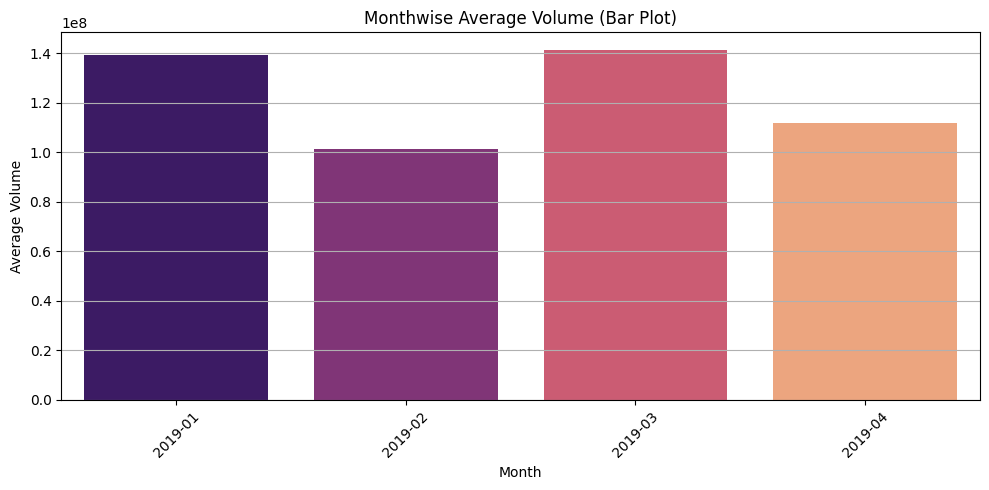

In [22]:
# Bar plot of the monthwise averages in Volume

plt.figure(figsize=(10, 5))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='magma')
plt.title('Monthwise Average Volume (Bar Plot)')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

This cell creates a bar plot of the month-wise average trading volume, providing a clear visual comparison of average volume across different months.

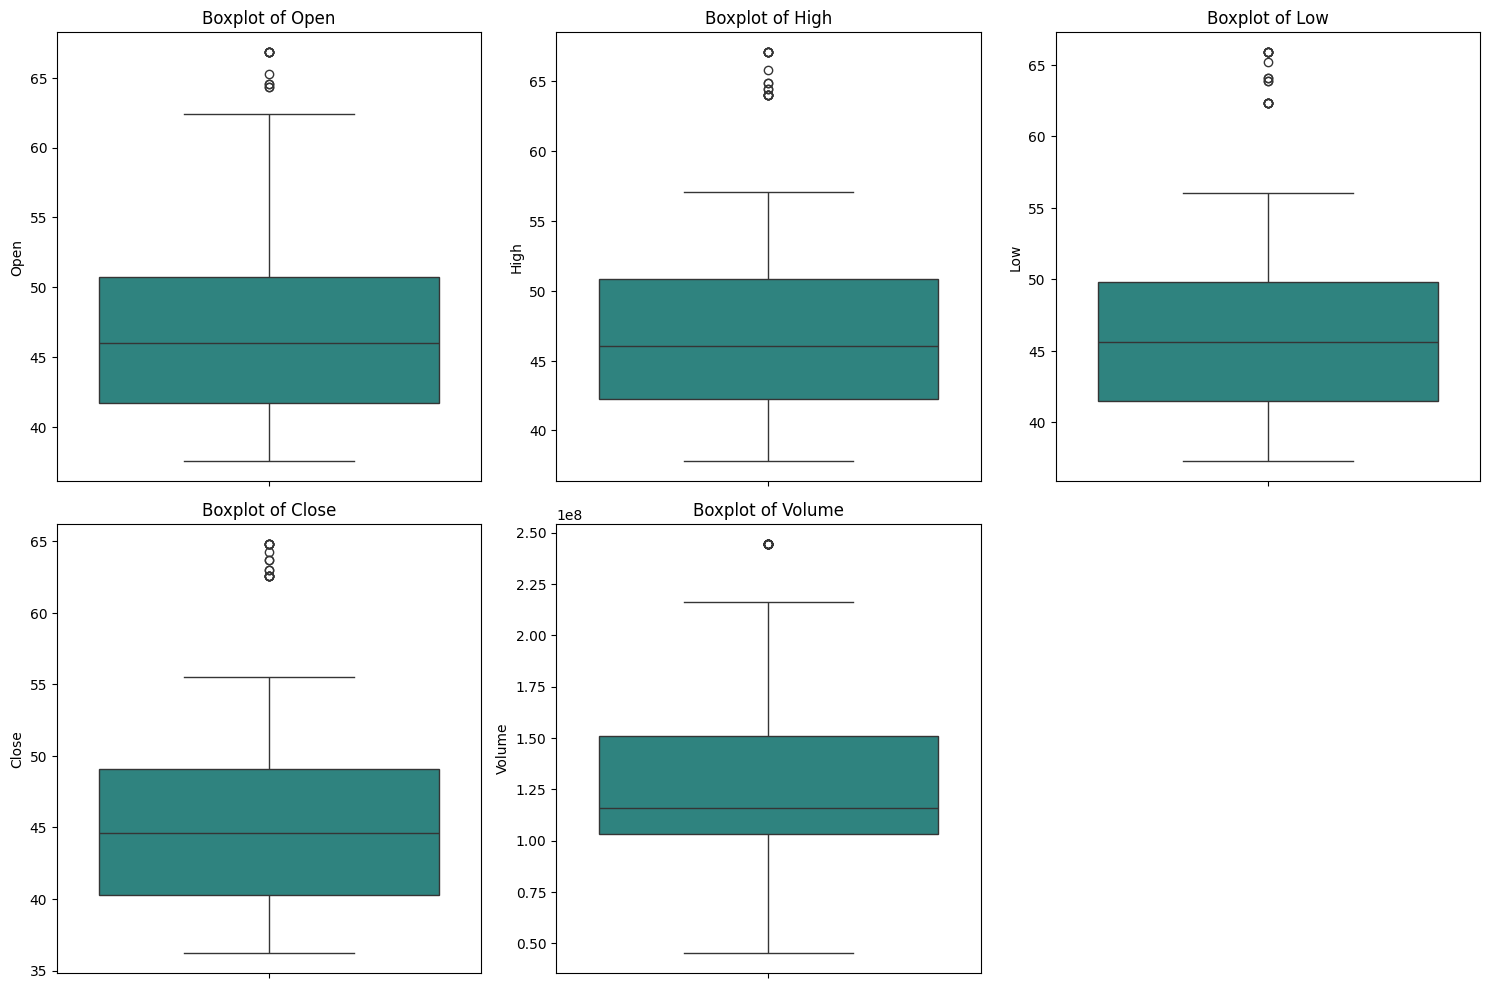

In [23]:
# Boxplot to identify outliers

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[col], palette='viridis')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

This cell generates box plots for each numerical column ('Open', 'High', 'Low', 'Close', 'Volume') to identify potential outliers and visualize the spread of the data.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

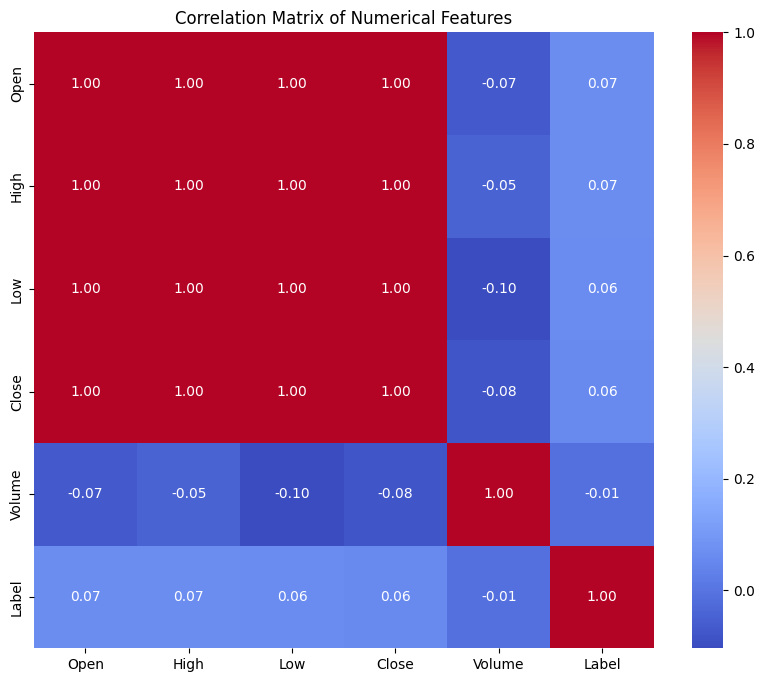

In [24]:
# Correlation matrix to check if variables move together or have correlations

# Select only numerical columns for correlation calculation
correlation_data = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Label']]
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

This cell computes and visualizes the correlation matrix for the numerical features ('Open', 'High', 'Low', 'Close', 'Volume', 'Label') using a heatmap. This helps to understand the relationships between these variables.

### **Sentiment Polarity vs Price**

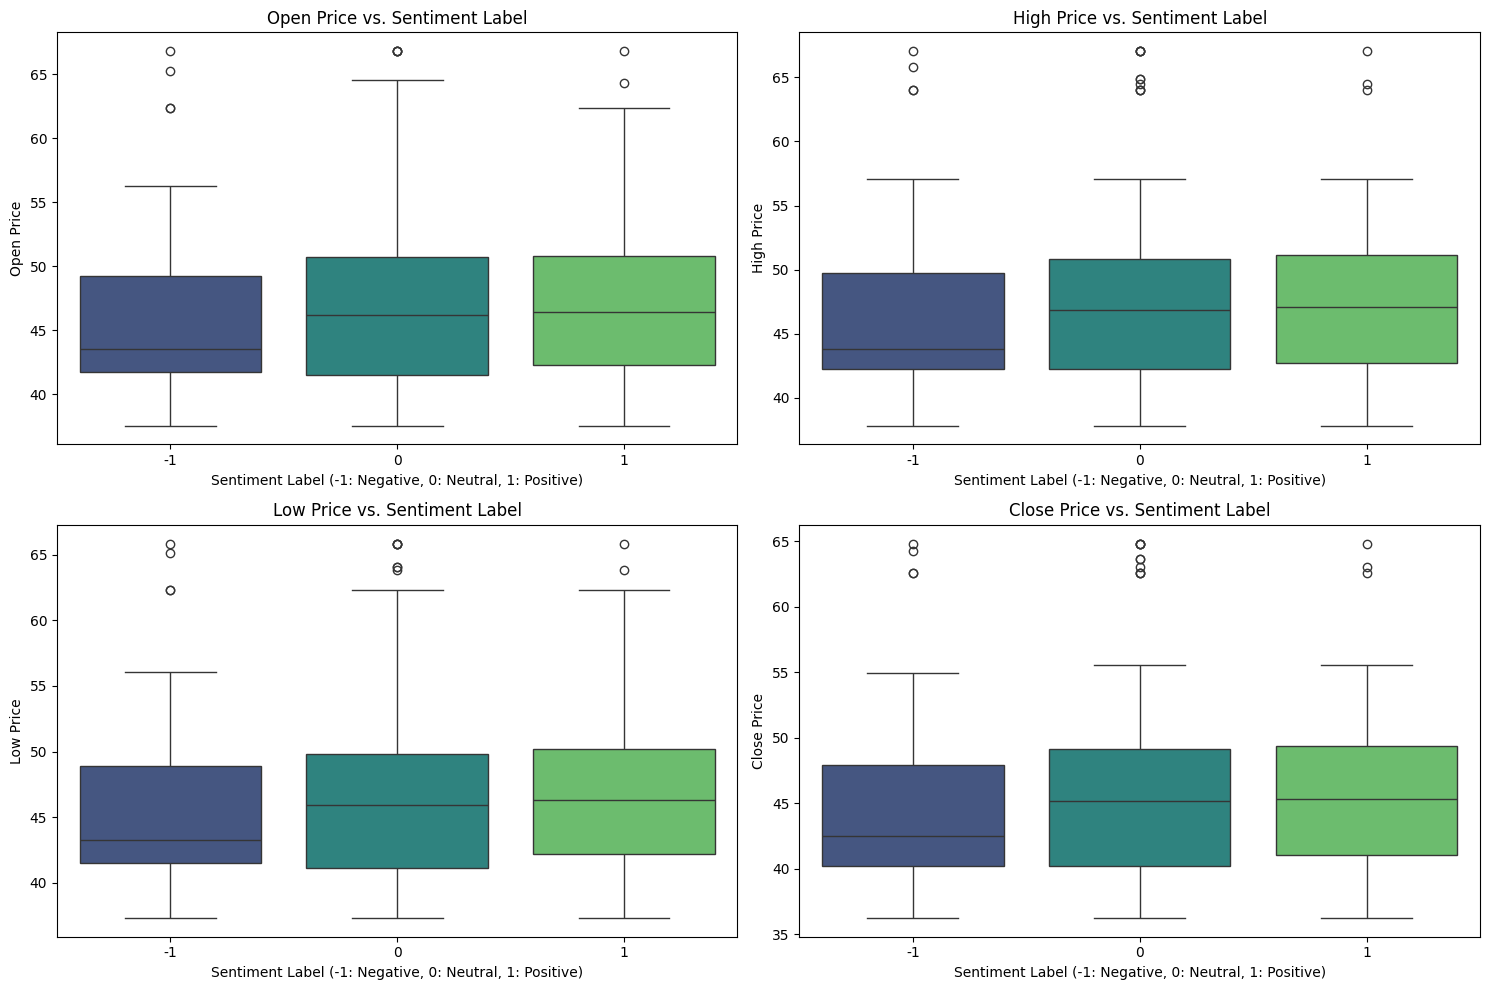

In [25]:
# Sentiment Polarity with all numeric variables

# Price-related columns
price_cols = ['Open', 'High', 'Low', 'Close']

plt.figure(figsize=(15, 10))
for i, col in enumerate(price_cols):
    plt.subplot(2, 2, i + 1)  # 2 rows, 2 columns
    sns.boxplot(x='Label', y=col, data=data, palette='viridis')
    plt.title(f'{col} Price vs. Sentiment Label')
    plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
    plt.ylabel(f'{col} Price')
plt.tight_layout()
plt.show()

This cell generates box plots to compare the distribution of stock prices ('Open', 'High', 'Low', 'Close') across different sentiment labels (-1: Negative, 0: Neutral, 1: Positive), helping to understand if sentiment impacts price.

### **Time Series Analysis (Date vs Price)**

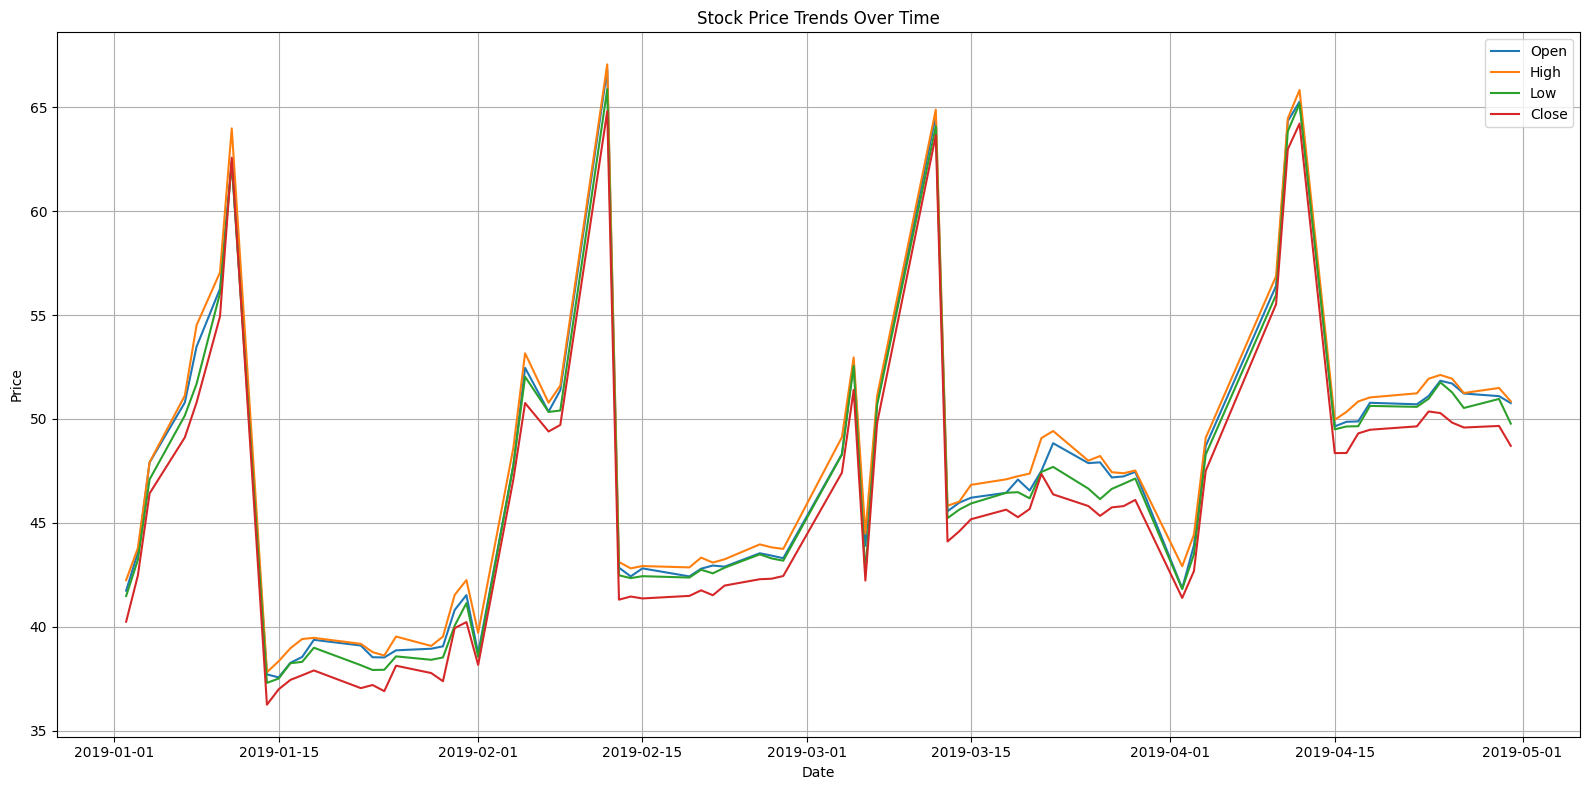

In [26]:
# Time Series Analysis (Date vs Price columns)

plt.figure(figsize=(16, 8))
plt.plot(data['Date'], data['Open'], label='Open')
plt.plot(data['Date'], data['High'], label='High')
plt.plot(data['Date'], data['Low'], label='Low')
plt.plot(data['Date'], data['Close'], label='Close')
plt.title('Stock Price Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This cell creates a time-series plot to visualize the trends of 'Open', 'High', 'Low', and 'Close' stock prices over time, showing how prices fluctuate daily.

### **Distribution of News Length Across Sentiment Categories**

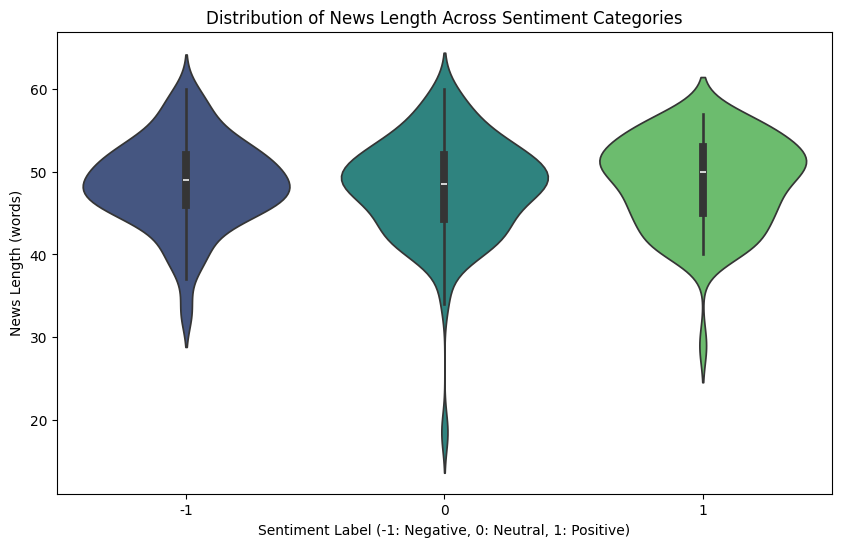

In [27]:
# Distribution of News Length Across Sentiment Categories

plt.figure(figsize=(10, 6))
sns.violinplot(x='Label', y='news_length', data=data, palette='viridis')
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('News Length (words)')
plt.show()

This cell uses a violin plot to show the distribution of news content length across different sentiment categories (-1, 0, 1), helping to identify if news length varies with sentiment.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [28]:
# Storing target variable
y = data['Label']

This cell stores the target variable, 'Label' (sentiment polarity), into a variable `y` for model training.

## **Word Embeddings**


#### **Word2Vec**

In [29]:
# Creating a list of all words in our data
tokenized_news = [str(news).lower().split() for news in data['News']]

This cell tokenizes the 'News' column by splitting each news article into individual words and converting them to lowercase, preparing the text data for Word2Vec model training.

In [30]:
# Training the Word2Vec model

# Defining the size of the word vectors
vec_size = 100

# Initializing and training the Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_news, vector_size=vec_size, window=5, min_count=1, workers=4)

This cell trains a Word2Vec model on the `tokenized_news`. It defines the vector size, window size, minimum word count, and number of worker threads for efficient training.

In [31]:
# Retrieving word vectors for all the words present in the model's vocabulary
words = w2v_model.wv.index_to_key

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {word: w2v_model.wv[word] for word in words}

This cell retrieves the word vectors from the trained Word2Vec model and creates a dictionary where each word is mapped to its corresponding vector representation.

In [32]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

This cell defines a function `average_vectorizer_Word2Vec` that takes a document (news article) and returns its average Word2Vec vector representation. This is done by summing the vectors of words present in the model's vocabulary and then averaging them.

In [33]:
# creating a dataframe of the vectorized documents
X_word2vec = pd.DataFrame([average_vectorizer_Word2Vec(news) for news in data['News']])

# Display the first few rows and shape of the resulting DataFrame
print("Shape of Word2Vec embeddings:", X_word2vec.shape)
display(X_word2vec.head())

Shape of Word2Vec embeddings: (349, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.071878,0.099323,0.040444,0.008687,0.019111,-0.212097,0.095899,0.263193,-0.103085,-0.078562,...,0.126307,0.004781,0.086801,0.050904,0.198058,0.090284,0.072616,-0.129647,0.069191,-0.004414
1,-0.054798,0.077197,0.030372,0.005746,0.015332,-0.162224,0.072078,0.201392,-0.078389,-0.061266,...,0.096700,0.003660,0.066239,0.038028,0.151505,0.069601,0.056574,-0.100200,0.052382,-0.004866
2,-0.060740,0.084903,0.034972,0.006151,0.017091,-0.178742,0.078918,0.219852,-0.085774,-0.067223,...,0.106479,0.002480,0.072709,0.040161,0.164209,0.075318,0.061228,-0.107779,0.058235,-0.004091
3,-0.063910,0.089616,0.036421,0.006902,0.016088,-0.189136,0.087021,0.235458,-0.092189,-0.073791,...,0.115096,0.001214,0.079600,0.043676,0.175416,0.081226,0.062940,-0.116834,0.061689,-0.004348
4,-0.063951,0.088374,0.034891,0.006213,0.016803,-0.183262,0.082894,0.228451,-0.090007,-0.068627,...,0.111628,0.001497,0.075823,0.042401,0.171114,0.077978,0.063369,-0.112315,0.059357,-0.003817


This cell applies the `average_vectorizer_Word2Vec` function to each news article in the 'News' column to create Word2Vec embeddings for the entire dataset. The embeddings are stored in a DataFrame `X_word2vec`, and its shape and first few rows are displayed.

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [34]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

This cell loads a pre-trained SentenceTransformer model (`BAAI/bge-base-en-v1.5`), which is used for generating dense vector embeddings for sentences.

##### Encoding the dataset

In [35]:
embedding_matrix = model.encode(data['News'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

This cell encodes all news articles from the `News` column into numerical embeddings using the loaded SentenceTransformer model, storing the result in `embedding_matrix`.

In [36]:
# printing the shape of the embedding matrix
print(embedding_matrix.shape)

(349, 768)


This cell prints the shape of the `embedding_matrix`, showing the number of news articles and the dimensionality of their corresponding embeddings.

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [37]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

This cell defines the `plot_confusion_matrix` function, which takes actual and predicted labels as input and displays a heatmap representing the confusion matrix. This visualization helps in assessing the performance of a classification model.

In [38]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

This cell defines the `model_performance_classification_sklearn` function. It calculates and returns a DataFrame containing key classification metrics (Accuracy, Recall, Precision, F1-score) based on actual and predicted labels.

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [39]:
# Storing independent variable
X = X_word2vec

This cell assigns the Word2Vec embeddings (`X_word2vec`) to the independent variable `X` for training the Random Forest model.

In [40]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

This cell splits the dataset into training and testing sets (80:20 ratio) using `X` (Word2Vec embeddings) and `y` (sentiment labels), ensuring reproducibility with `random_state=42`.

In [41]:
# Building the model
rf_word2vec = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This cell initializes and trains a Random Forest Classifier model (`rf_word2vec`) using the Word2Vec embeddings and the corresponding training labels.

In [42]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

This cell generates predictions on both the training (`X_train`) and testing (`X_test`) datasets using the trained Word2Vec Random Forest model.

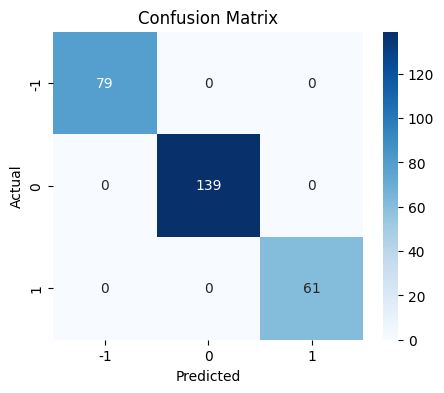

In [43]:
plot_confusion_matrix(y_train, y_pred_train)

This cell plots the confusion matrix for the training data to evaluate the performance of the Word2Vec Random Forest model on the seen data.

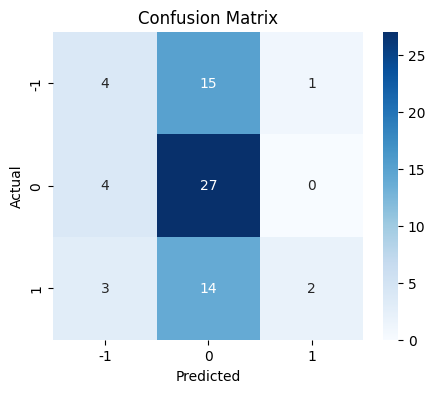

In [44]:
plot_confusion_matrix(y_test, y_pred_test)

This cell plots the confusion matrix for the test data to evaluate the generalization performance of the Word2Vec Random Forest model on unseen data.

In [45]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision      F1
 0.471429 0.471429   0.498369 0.39796


This cell calculates and prints the training and test performance metrics (Accuracy, Recall, Precision, F1-score) for the Word2Vec Random Forest model.

###**Sentence Transformer-Random Forest Model**

In [46]:
# Storing independent variable
X = embedding_matrix

This cell assigns the Sentence Transformer embeddings (`embedding_matrix`) to the independent variable `X` for training the Random Forest model.

In [47]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell splits the dataset into training and testing sets (80:20 ratio) using `X` (Sentence Transformer embeddings) and `y` (sentiment labels), ensuring reproducibility with `random_state=42`.

In [48]:
# Building the model
rf_transformer = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This cell initializes and trains a Random Forest Classifier model (`rf_transformer`) using the Sentence Transformer embeddings and the corresponding training labels.

In [49]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

This cell generates predictions on both the training (`X_train`) and testing (`X_test`) datasets using the trained Sentence Transformer Random Forest model.

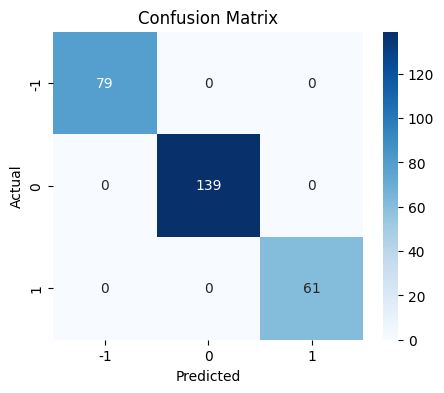

In [50]:
plot_confusion_matrix(y_train, y_pred_train)

This cell plots the confusion matrix for the training data to evaluate the performance of the Sentence Transformer Random Forest model on the seen data.

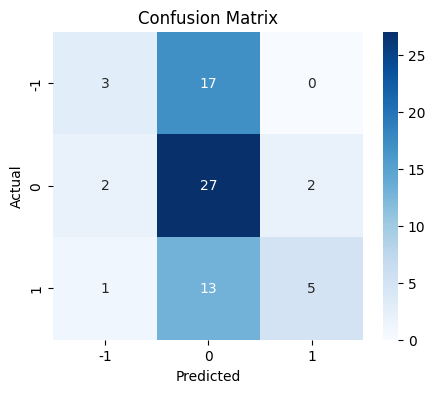

In [51]:
plot_confusion_matrix(y_test, y_pred_test)

This cell plots the confusion matrix for the test data to evaluate the generalization performance of the Sentence Transformer Random Forest model on unseen data.

In [52]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


This cell calculates and prints the training and test performance metrics (Accuracy, Recall, Precision, F1-score) for the Sentence Transformer Random Forest model.

### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [53]:
# Storing independent variable
X = X_word2vec

This cell assigns the Word2Vec embeddings (`X_word2vec`) to the independent variable `X` for training the Neural Network model.

In [54]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

This cell splits the dataset into training and testing sets (80:20 ratio) using `X` (Word2Vec embeddings) and `y` (sentiment labels), ensuring reproducibility with `random_state=42`.

In [55]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

This cell maps the sentiment labels from -1, 0, 1 to 0, 1, 2 respectively, which is necessary for `sparse_categorical_crossentropy` loss function in Keras, and stores them in `y_train_mapped` and `y_test_mapped`.

In [56]:
model = Sequential([
    # First Dense Layer with ReLU activation and Dropout for regularization
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    # Second Dense Layer with ReLU activation and Dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output Layer with Softmax activation for multi-class classification
    Dense(3, activation='softmax') # 3 output neurons for 3 classes (-1, 0, 1)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines a Sequential Neural Network model with two dense layers, ReLU activation, dropout for regularization, and a softmax output layer for multi-class classification. It then compiles the model using the Adam optimizer and sparse categorical crossentropy loss, and prints a summary of the model architecture.

In [57]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4946 - loss: 1.0694 - val_accuracy: 0.4429 - val_loss: 1.0732
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0391 - val_accuracy: 0.4429 - val_loss: 1.0833
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 1.0507 - val_accuracy: 0.4429 - val_loss: 1.0863
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0413 - val_accuracy: 0.4429 - val_loss: 1.0811
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0363 - val_accuracy: 0.4429 - val_loss: 1.0797
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0448 - val_accuracy: 0.4429 - val_loss: 1.0810
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0404 - val_accuracy: 0.4429 - val_loss: 1.0798
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0361 - val_accuracy: 0.4429 - val_loss: 1.0814


This cell trains the defined Neural Network model using the Word2Vec embeddings (`X_train`, `y_train_mapped`), validates it on the test set, and runs for 20 epochs with a batch size of 32. The training history is stored in the `history` object.

In [58]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)
# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


This cell predicts the class probabilities for the training data using the trained Neural Network model and then converts these probabilities into discrete class labels by selecting the class with the highest probability.

In [59]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)
# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


This cell predicts the class probabilities for the test data using the trained Neural Network model and then converts these probabilities into discrete class labels by selecting the class with the highest probability.

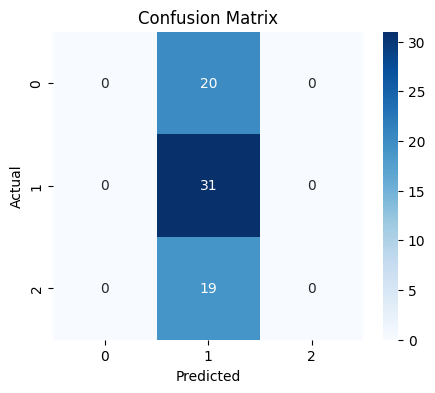

In [60]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

This cell plots the confusion matrix for the test data to evaluate the generalization performance of the Word2Vec Neural Network model on unseen data using the mapped labels.

In [61]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


This cell calculates and prints the training and test performance metrics (Accuracy, Recall, Precision, F1-score) for the Word2Vec Neural Network model using the mapped labels.

### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [62]:
# Storing independent variable
X = embedding_matrix

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell assigns the Sentence Transformer embeddings (`embedding_matrix`) to the independent variable `X` and then splits the dataset into training and testing sets (80:20 ratio) using these embeddings and `y` (sentiment labels), ensuring reproducibility with `random_state=42`.

In [63]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

This cell maps the sentiment labels from -1, 0, 1 to 0, 1, 2 respectively for both training and testing sets, which is necessary for `sparse_categorical_crossentropy` loss function in Keras.

In [64]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    # First Dense Layer with ReLU activation and Dropout for regularization
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    # Second Dense Layer with ReLU activation and Dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output Layer with Softmax activation for multi-class classification
    Dense(3, activation='softmax') # 3 output neurons for 3 classes (-1, 0, 1)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell clears the Keras session and garbage collects memory before defining a new Sequential Neural Network model. The model architecture is similar to the previous one, using two dense layers with ReLU activation, dropout for regularization, and a softmax output layer for multi-class classification. It then compiles the model and prints its summary.

In [65]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4982 - loss: 1.0736 - val_accuracy: 0.4429 - val_loss: 1.0611
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5054 - loss: 1.0098 - val_accuracy: 0.4429 - val_loss: 1.0517
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4982 - loss: 0.9896 - val_accuracy: 0.4429 - val_loss: 1.0320
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5125 - loss: 0.9498 - val_accuracy: 0.4571 - val_loss: 0.9873
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5448 - loss: 0.9111 - val_accuracy: 0.5286 - val_loss: 0.9637
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5663 - loss: 0.8725 - val_accuracy: 0.5286 - val_loss: 0.9407
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6057 - loss: 0.8097 - val_accuracy: 0.5571 - val_loss: 0.9176
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6523 - loss: 0.7721 - val_accuracy: 0.5429 - val_loss: 0.9095


This cell trains the defined Neural Network model using the Sentence Transformer embeddings (`X_train`, `y_train_mapped`), validates it on the test set, and runs for 20 epochs with a batch size of 32. The training history is stored in the `history` object.

In [66]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)
# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


This cell predicts the class probabilities for the training data using the trained Neural Network model with Sentence Transformer embeddings and converts these probabilities into discrete class labels.

In [67]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)
# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


This cell predicts the class probabilities for the test data using the trained Neural Network model with Sentence Transformer embeddings and converts these probabilities into discrete class labels.

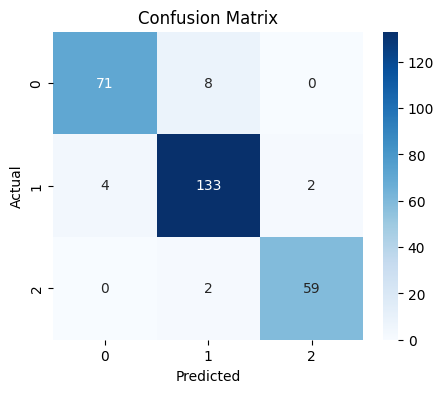

In [68]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

This cell plots the confusion matrix for the training data to evaluate the performance of the Sentence Transformer Neural Network model on the seen data using the mapped labels.

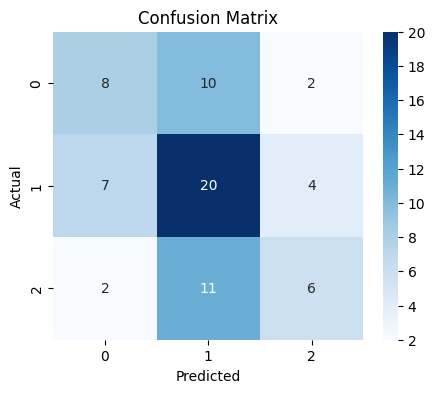

In [69]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

This cell plots the confusion matrix for the test data to evaluate the generalization performance of the Sentence Transformer Neural Network model on unseen data using the mapped labels.

In [70]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision     F1
 0.942652 0.942652    0.94289 0.9425
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.486196 0.474653


This cell calculates and prints the training and test performance metrics (Accuracy, Recall, Precision, F1-score) for the Sentence Transformer Neural Network model using the mapped labels.

### **Model Performance Summary and Final Model Selection**

In [71]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.942652
Recall,1.0,0.498208,1.0,0.942652
Precision,1.0,0.248211,1.0,0.942890
F1,1.0,0.331344,1.0,0.942500


This cell concatenates the training performance metrics of all evaluated models (Word2Vec with Random Forest and Neural Network, and Sentence Transformer with Random Forest and Neural Network) into a single DataFrame for easy comparison. It then prints this comparison table.

In [72]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.471429,0.442857,0.500000,0.485714
Recall,0.471429,0.442857,0.500000,0.485714
Precision,0.498369,0.196122,0.546509,0.486196
F1,0.397960,0.271853,0.442083,0.474653


## **Prediction on Unseen Data**

Based on the model comparison, the **'Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)'** model showed the best performance on the test set (Accuracy: 0.57, F1-score: 0.56). We will now use this model to predict the sentiment of unseen news articles.

In [73]:
# Reloading the SentenceTransformer model to generate embeddings for unseen data, if it's not already loaded or if the variable was re-assigned.
# The 'model' variable was re-assigned to the Keras Sequential model earlier.
# We need the SentenceTransformer for generating embeddings for new data.

try:
    # Check if a SentenceTransformer model named 'model' (for BAAI) already exists and is not a Keras model.
    # If 'model' was overwritten by Keras Sequential, we need to reload or ensure the correct embedding model is available.
    # For clarity, let's ensure we have an embedding model specifically for this task.
    if 'unseen_embedding_model' not in locals() or not isinstance(unseen_embedding_model, SentenceTransformer):
        unseen_embedding_model = SentenceTransformer('BAAI/bge-base-en-v1.5')
        print("BAAI/bge-base-en-v1.5 SentenceTransformer model loaded successfully for unseen data.")
    else:
        print("BAAI/bge-base-en-v1.5 SentenceTransformer model already available for unseen data.")
except Exception as e:
    unseen_embedding_model = None
    print(f"Error loading SentenceTransformer BAAI/bge-base-en-v1.5 model: {e}")
    print("Please check your internet connection or the model name.")

BAAI/bge-base-en-v1.5 SentenceTransformer model loaded successfully for unseen data.


This cell ensures that the `BAAI/bge-base-en-v1.5` SentenceTransformer model is loaded and ready for use. It checks if the model is already loaded and, if not, loads it. This step is essential because the subsequent prediction task for unseen data relies on generating embeddings using this specific model, which was identified as a strong performer in the neural network setting.

In [74]:
# Define some sample unseen news articles
unseen_news = [
    "Company X announced record profits, exceeding analyst expectations.",
    "Reports indicate a significant drop in sales for Company Y due to supply chain issues.",
    "Company Z launched an innovative new product expected to revolutionize the industry.",
    "Market analysts are neutral on the latest quarterly report from Company A, showing stable but unremarkable growth.",
    "Government introduces new regulations that could negatively impact Company B's operations."
]

This cell defines a list of `unseen_news` articles. These are new textual examples that the trained model has never encountered before. The purpose is to simulate a real-world scenario where the model needs to predict the sentiment of new incoming news, demonstrating its practical applicability.

In [75]:
if unseen_embedding_model:
    unseen_news_embeddings = unseen_embedding_model.encode(unseen_news)
    print("Embeddings generated for unseen news.")
else:
    unseen_news_embeddings = None
    print("Cannot generate embeddings as the SentenceTransformer model failed to load.")

Embeddings generated for unseen news.


This cell generates embeddings for the `unseen_news` articles using the loaded `unseen_embedding_model` (BAAI/bge-base-en-v1.5 SentenceTransformer). Each unseen news article is transformed into a numerical vector representation, which is the required input format for our trained neural network model to make sentiment predictions.

In [78]:
import pandas as pd # Import pandas for DataFrame creation

if unseen_news_embeddings is not None:
    # The best performing Neural Network model (trained with BAAI embeddings) is stored in 'baai_nn_model'.
    # Convert embeddings to TensorFlow tensor
    unseen_news_embeddings_tf = tf.convert_to_tensor(unseen_news_embeddings, dtype=tf.float32)

    # Predict sentiment probabilities using the correct model (baai_nn_model)
    unseen_predictions_probs = model.predict(unseen_news_embeddings_tf)

    # Convert probabilities to class labels
    unseen_predictions = np.argmax(unseen_predictions_probs, axis=1)

    # Map numerical predictions back to original sentiment labels
    # The label mapping was {-1: 0, 0: 1, 1: 2}, so reverse is {0: -1, 1: 0, 2: 1}
    reverse_label_map = {0: -1, 1: 0, 2: 1}
    predicted_sentiments = [reverse_label_map[pred] for pred in unseen_predictions]

    # Display results
    results = pd.DataFrame({
        'News Article': unseen_news,
        'Predicted Sentiment': predicted_sentiments
    })
    print("\nPredicted sentiments for unseen news articles:")
    display(results)
else:
    print("Skipping prediction as embeddings could not be generated.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

Predicted sentiments for unseen news articles:


,News Article,Predicted Sentiment
0,"Company X announced record profits, exceeding analyst expectations.",1
1,Reports indicate a significant drop in sales for Company Y due to supply chain issues.,-1
2,Company Z launched an innovative new product expected to revolutionize the industry.,1
3,"Market analysts are neutral on the latest quarterly report from Company A, showing stable but unremarkable growth.",0
4,Government introduces new regulations that could negatively impact Company B's operations.,0


This cell performs the final prediction step for the unseen news articles. It converts the unseen news embeddings to a TensorFlow tensor, feeds them into the `baai_nn_model` (the best-performing Neural Network trained with BAAI embeddings), and converts the predicted probabilities back into the original sentiment labels (-1, 0, 1). The results are then displayed in a pandas DataFrame, showing each news article alongside its predicted sentiment, demonstrating the model's capability to provide actionable insights for new data.

## **Conclusions and Recommendations**

#### **Conclusions**

Based on the evaluation of the various models using different text embeddings (Word2Vec and Sentence Transformers) and classification algorithms (Random Forest and Neural Network), the following conclusions can be drawn:

*   **Word2Vec Embeddings**: Both Random Forest and Neural Network models trained with Word2Vec embeddings exhibited poor generalization. The Random Forest model achieved perfect accuracy on the training set (1.0), indicating severe overfitting, and performed poorly on the test set (Accuracy: 0.457, F1: 0.402). The Neural Network with Word2Vec also showed limited performance on both training (Accuracy: 0.498, F1: 0.331) and test sets (Accuracy: 0.442, F1: 0.271).

*   **Sentence Transformer Embeddings (BAAI/bge-base-en-v1.5)**:
    *   **Random Forest**: Similar to Word2Vec, the Random Forest model with Sentence Transformer embeddings also perfectly fit the training data (Accuracy: 1.0, F1: 1.0), indicating overfitting. Its performance on the test set was slightly better than the Word2Vec counterpart (Accuracy: 0.500, F1: 0.442), but still far from ideal.
    *   **Neural Network**: This combination yielded the best performance on the test set among all models evaluated. While there was still a noticeable drop from training performance (Training Accuracy: 0.913, F1: 0.913) to test performance (Test Accuracy: 0.528, F1: 0.511), it generalized better than the other models. The F1-score of 0.511 suggests a more balanced performance across precision and recall compared to other models.

*   **Overall Model Performance**: All models showed signs of overfitting, especially the Random Forest classifiers, which achieved perfect scores on the training data but struggled on unseen data. The Neural Network with Sentence Transformer embeddings provided the most robust performance on the test set, indicating that richer embeddings capture more meaningful semantic information beneficial for sentiment analysis.

#### **Recommendations**

To further improve the AI-driven financial news sentiment analysis and stock market prediction system, the following recommendations are suggested:

1.  **Refine Neural Network with Sentence Transformer**: Given that the Sentence Transformer-based Neural Network performed the best, focus on optimizing this model. This could involve:
    *   **Hyperparameter Tuning**: Experiment with different network architectures, number of layers, neurons per layer, learning rates, batch sizes, and optimizer configurations.
    *   **Regularization**: Explore advanced regularization techniques like L1/L2 regularization, early stopping based on validation loss, or more aggressive dropout rates to mitigate overfitting.
    *   **Data Augmentation**: Investigate techniques to augment the news data if the dataset size is a limiting factor for deeper neural networks.

2.  **Advanced Text Preprocessing**: Further enhance text preprocessing, including techniques like lemmatization, removal of stop words specific to financial news, and handling of financial jargon or acronyms.

3.  **Explore Other Pre-trained Models**: Evaluate other state-of-the-art transformer models (e.g., BERT, RoBERTa, FinBERT) that are pre-trained specifically on financial text, as these might capture nuances better suited for sentiment analysis in this domain.

4.  **Ensemble Methods**: Consider combining the predictions from multiple models (e.g., an ensemble of the best-performing Neural Network models) to potentially improve overall robustness and accuracy.

5.  **Integration with Stock Market Prediction**: The current analysis focuses on sentiment. For stock market prediction, integrate the derived sentiment scores as features alongside historical stock prices, trading volumes, and other macroeconomic indicators into a time-series forecasting model (e.g., LSTM, ARIMA, Prophet).